<a href="https://colab.research.google.com/github/tratramcute/hellovalentine.github.io/blob/main/Datathon_Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (simple seasonal average + trend):**
1. Compute average YoY growth rate from 2013–2022.
2. Build a "seasonal profile" — the average Revenue/COGS for each calendar day-of-year across all historical years.
3. Scale the profile by the projected year-level trend to produce predictions.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

file_path = '/content/drive/MyDrive/dataset'

DATA_DIR  = file_path + '/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE  = DATA_DIR + 'test.csv'
OUT_FILE   = DATA_DIR + 'submission.csv'

### 2 — Load & Inspect Data

In [71]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(DATA_DIR + 'sample_submission.csv', parse_dates=['Date'])  # dùng Date từ file submission để thay thế

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


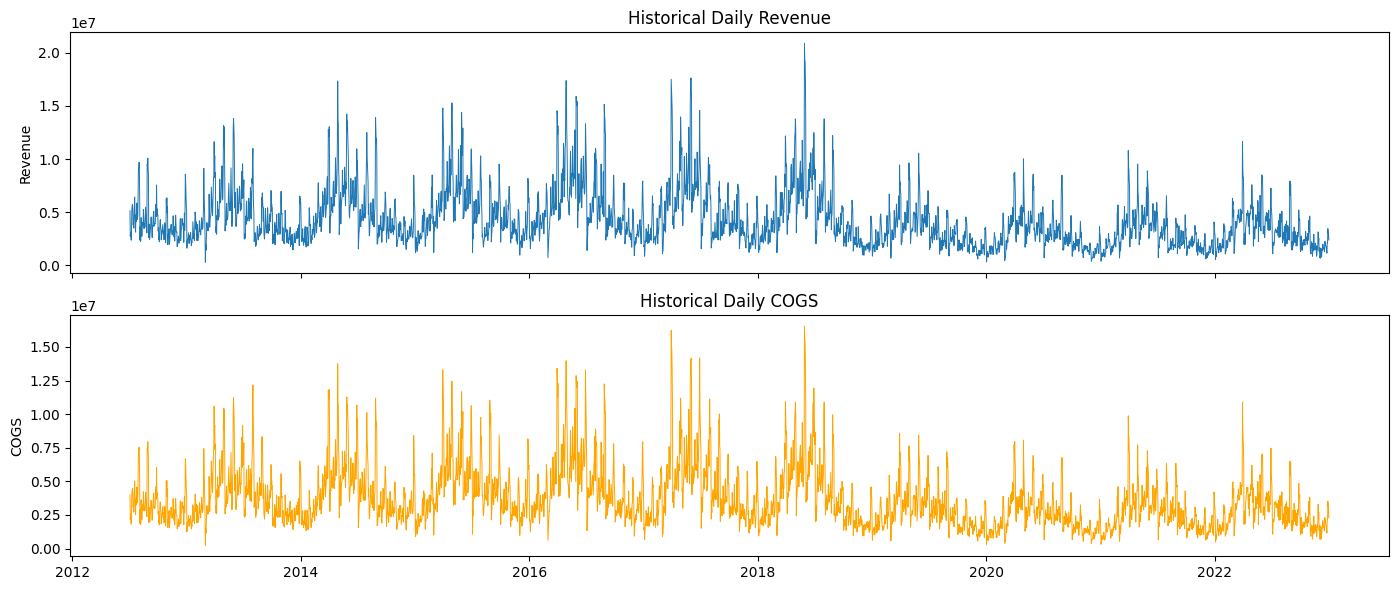

In [73]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

In [74]:
# Kiểm tra chi tiết dữ liệu
print(f'Shape của dữ liệu: {train.shape}')
print('\nKiểm tra giá trị thiếu (Missing Values):')
print(train.isnull().sum())

# Thống kê mô tả
display(train.describe())

Shape của dữ liệu: (3833, 3)

Kiểm tra giá trị thiếu (Missing Values):
Date       0
Revenue    0
COGS       0
dtype: int64


,Date,Revenue,COGS
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06


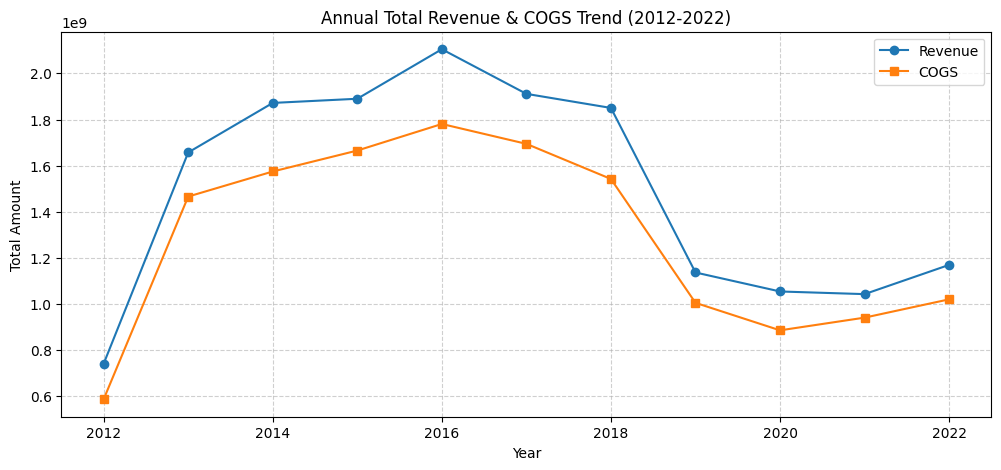

In [75]:
import matplotlib.pyplot as plt

# Ensure 'year' column exists
if 'year' not in train.columns:
    train['year'] = train['Date'].dt.year

# Tính tổng theo năm
annual_trend = train.groupby('year')[['Revenue', 'COGS']].sum()

plt.figure(figsize=(12, 5))
plt.plot(annual_trend.index, annual_trend['Revenue'], marker='o', label='Revenue', color='tab:blue')
plt.plot(annual_trend.index, annual_trend['COGS'], marker='s', label='COGS', color='tab:orange')

plt.title('Annual Total Revenue & COGS Trend (2012-2022)')
plt.xlabel('Year')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## 3 — Feature Engineering

In [76]:
train['year']       = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day']        = train['Date'].dt.day

# Annual totals — used to estimate YoY growth
annual = train.groupby('year')[['Revenue', 'COGS']].sum()
print('Annual totals (only complete years shown):')
print(annual)

Annual totals (only complete years shown):
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


In [77]:
# 1. Additional Time Features
train['day_of_week']   = train['Date'].dt.dayofweek
train['quarter']       = train['Date'].dt.quarter
train['week_of_year'] = train['Date'].dt.isocalendar().week.astype(int)

# 2. Lag Features (Dịch chuyển dữ liệu)
for lag in [7, 14, 30, 365]:
    train[f'rev_lag_{lag}'] = train['Revenue'].shift(lag)
    train[f'cogs_lag_{lag}'] = train['COGS'].shift(lag)

# 3. Rolling Window Features (Trung bình trượt)
for window in [7, 30]:
    train[f'rev_roll_mean_{window}'] = train['Revenue'].transform(lambda x: x.rolling(window).mean())
    train[f'cogs_roll_mean_{window}'] = train['COGS'].transform(lambda x: x.rolling(window).mean())

# 4. Seasonal Flags
train['is_weekend']    = (train['day_of_week'] >= 5).astype(int)
train['is_month_end']  = train['Date'].dt.is_month_end.astype(int)
train['is_quarter_end'] = train['Date'].dt.is_quarter_end.astype(int)

# 5. Trend Feature (Số ngày kể từ điểm bắt đầu)
min_date = train['Date'].min()
train['trend_days'] = (train['Date'] - min_date).dt.days

print('Advanced features created. Shape:', train.shape)
display(train.tail())


Advanced features created. Shape: (3833, 26)


,Date,Revenue,COGS,year,day_of_year,month,day,day_of_week,quarter,week_of_year,...,rev_lag_365,cogs_lag_365,rev_roll_mean_7,cogs_roll_mean_7,rev_roll_mean_30,cogs_roll_mean_30,is_weekend,is_month_end,is_quarter_end,trend_days
3828,2022-12-27,2100553.66,2184872.24,2022,361,12,27,1,4,52,...,1025037.51,986082.95,1.689608e+06,1.712507e+06,1.554530e+06,1.589892e+06,0,0,0,3828
3829,2022-12-28,3448729.20,3513621.00,2022,362,12,28,2,4,52,...,1855064.19,1847193.90,1.925798e+06,1.956326e+06,1.599323e+06,1.635268e+06,0,0,0,3829
3830,2022-12-29,3083944.33,3170787.10,2022,363,12,29,3,4,52,...,4065184.90,4208667.70,2.110416e+06,2.155892e+06,1.616831e+06,1.651148e+06,0,0,0,3830
3831,2022-12-30,2884668.76,3022292.15,2022,364,12,30,4,4,52,...,3842586.50,3948015.94,2.308053e+06,2.373471e+06,1.669063e+06,1.707013e+06,0,0,0,3831
3832,2022-12-31,2383037.48,2279288.13,2022,365,12,31,5,4,52,...,3041203.79,3121467.33,2.449791e+06,2.498846e+06,1.692883e+06,1.726886e+06,1,1,1,3832


In [78]:
import os

TRAFFIC_FILE = DATA_DIR + 'web_traffic.csv'

if os.path.exists(TRAFFIC_FILE):
    # Đọc thử 1 vài dòng để kiểm tra tên cột
    df_check = pd.read_csv(TRAFFIC_FILE, nrows=0)
    cols = df_check.columns.tolist()
    print(f'Columns in web_traffic.csv: {cols}')

    # Tìm cột ngày tháng (không phân biệt hoa thường)
    date_col = next((c for c in cols if c.lower() == 'date'), None)

    if date_col:
        traffic = pd.read_csv(TRAFFIC_FILE, parse_dates=[date_col])
        # Chuẩn hóa tên cột về 'Date' để merge
        traffic = traffic.rename(columns={date_col: 'Date'})

        print('Traffic data shape:', traffic.shape)

        # Merge với train
        train = train.merge(traffic, on='Date', how='left')

        # Fill missing values với 0
        traffic_cols = [c for c in traffic.columns if c != 'Date']
        train[traffic_cols] = train[traffic_cols].fillna(0)

        print(f'Successfully merged {len(traffic_cols)} traffic columns.')
        display(train.tail())
    else:
        print(f'Error: Could not find a date column in {cols}')
else:
    print(f'Warning: {TRAFFIC_FILE} not found.')

Columns in web_traffic.csv: ['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'traffic_source']
Traffic data shape: (3652, 7)
Successfully merged 6 traffic columns.


,Date,Revenue,COGS,year,day_of_year,month,day,day_of_week,quarter,week_of_year,...,is_weekend,is_month_end,is_quarter_end,trend_days,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
3828,2022-12-27,2100553.66,2184872.24,2022,361,12,27,1,4,52,...,0,0,0,3828,17416.0,13150.0,62527.0,0.00506,252.4,organic_search
3829,2022-12-28,3448729.20,3513621.00,2022,362,12,28,2,4,52,...,0,0,0,3829,21071.0,15979.0,67456.0,0.00560,177.3,organic_search
3830,2022-12-29,3083944.33,3170787.10,2022,363,12,29,3,4,52,...,0,0,0,3830,20884.0,14640.0,82155.0,0.00522,165.6,direct
3831,2022-12-30,2884668.76,3022292.15,2022,364,12,30,4,4,52,...,0,0,0,3831,17679.0,13713.0,79308.0,0.00350,183.8,email_campaign
3832,2022-12-31,2383037.48,2279288.13,2022,365,12,31,5,4,52,...,1,1,1,3832,21743.0,15512.0,94844.0,0.00394,151.7,organic_search


## 4 — Time-based Split (Train/Validation)
Avoiding leakage by splitting data chronologically.
- Train: 2012 – 2020
- Validation: 2021 – 2022

In [79]:
# Split data using 'year' column created in Feature Engineering
train_set = train[train['year'] <= 2020].copy()
val_set   = train[train['year'].isin([2021, 2022])].copy()

print(f'Train set range: {train_set["Date"].min().date()} to {train_set["Date"].max().date()} ({len(train_set)} rows)')
print(f'Val set range:   {val_set["Date"].min().date()} to {val_set["Date"].max().date()} ({len(val_set)} rows)')

# Kiểm tra tỉ lệ
total_rows = len(train)
print(f'Split ratio: {len(train_set)/total_rows:.1%} Train / {len(val_set)/total_rows:.1%} Val')

Train set range: 2012-07-04 to 2020-12-31 (3103 rows)
Val set range:   2021-01-01 to 2022-12-31 (730 rows)
Split ratio: 81.0% Train / 19.0% Val


## 5 — Model Training (LightGBM)
Training two separate models for Revenue and COGS using the features engineered above.

In [80]:
import lightgbm as lgb

# Xác định các features dùng để training
# Loại bỏ các cột mục tiêu, cột ngày tháng và các cột chứa giá trị NaN do Lag/Rolling
drop_cols = ['Date', 'Revenue', 'COGS', 'rev_norm', 'cogs_norm', 'traffic_source']
features = [c for c in train.columns if c not in drop_cols]

# Chuẩn bị dữ liệu (loại bỏ NaN từ Lag/Rolling features)
train_clean = train_set.dropna()
val_clean   = val_set.dropna()

X_train, y_rev_train, y_cogs_train = train_clean[features], train_clean['Revenue'], train_clean['COGS']
X_val,   y_rev_val,   y_cogs_val   = val_clean[features],   val_clean['Revenue'],   val_clean['COGS']

print(f'Training with {len(features)} features: {features}')

# 1. Model for Revenue
model_rev = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=31, random_state=42)
model_rev.fit(
    X_train, y_rev_train,
    eval_set=[(X_val, y_rev_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# 2. Model for COGS
model_cogs = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=31, random_state=42)
model_cogs.fit(
    X_train, y_cogs_train,
    eval_set=[(X_val, y_cogs_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

Training with 28 features: ['year', 'day_of_year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'rev_lag_7', 'cogs_lag_7', 'rev_lag_14', 'cogs_lag_14', 'rev_lag_30', 'cogs_lag_30', 'rev_lag_365', 'cogs_lag_365', 'rev_roll_mean_7', 'cogs_roll_mean_7', 'rev_roll_mean_30', 'cogs_roll_mean_30', 'is_weekend', 'is_month_end', 'is_quarter_end', 'trend_days', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4959
[LightGBM] [Info] Number of data points in the train set: 2738, number of used features: 28
[LightGBM] [Info] Start training from score 4566731.689372
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 5.72272e+11
[200]	valid_0's l2: 5.50983e+11
[300]	valid_0's l2: 5.47945e+11
Early stopping, best iteration is:
[270]	

LGBMRegressor(learning_rate=0.05, n_estimators=1000, random_state=42)

## 6 — Model Evaluation (LightGBM)
Calculating MAE, RMSE, and R² scores on the validation set.

--- Revenue Evaluation ---
MAE:  533,381.60
RMSE: 739,451.73
R2:   0.8032

--- COGS Evaluation ---
MAE:  463,083.28
RMSE: 658,740.23
R2:   0.7937



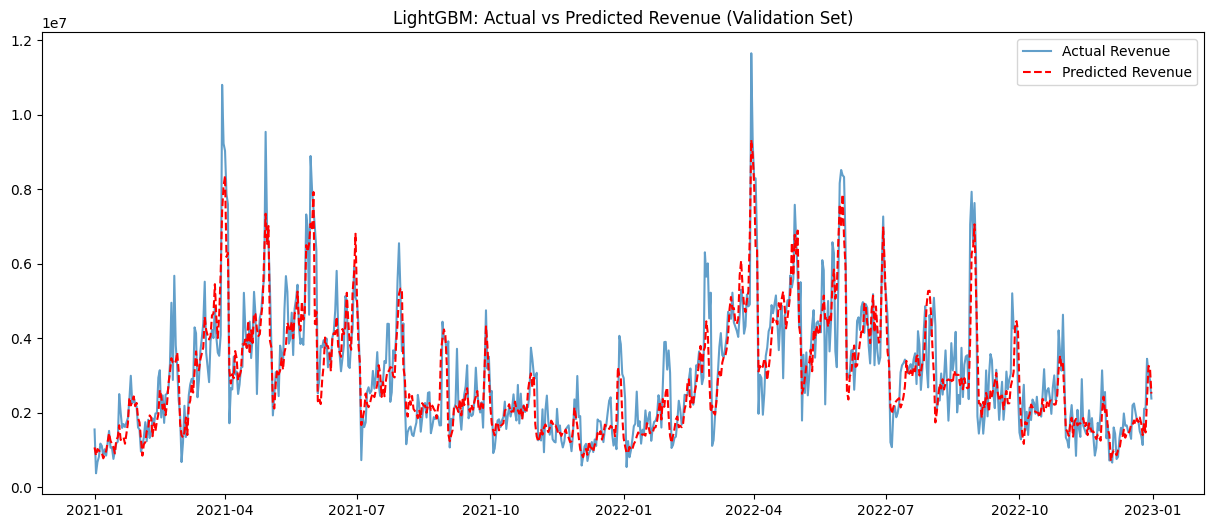

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dự báo trên tập validation
rev_pred = model_rev.predict(X_val)
cogs_pred = model_cogs.predict(X_val)

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'--- {name} Evaluation ---')
    print(f'MAE:  {mae:,.2f}')
    print(f'RMSE: {rmse:,.2f}')
    print(f'R2:   {r2:.4f}\n')

evaluate(y_rev_val, rev_pred, 'Revenue')
evaluate(y_cogs_val, cogs_pred, 'COGS')

# Plotting Actual vs Predicted
plt.figure(figsize=(15, 6))
plt.plot(val_clean['Date'], y_rev_val, label='Actual Revenue', alpha=0.7)
plt.plot(val_clean['Date'], rev_pred, label='Predicted Revenue', linestyle='--', color='red')
plt.title('LightGBM: Actual vs Predicted Revenue (Validation Set)')
plt.legend()
plt.show()

### Giải thích các chỉ số đánh giá

1. **R² (R-squared) ~ 0.80:** Con số này cho biết mô hình giải thích được **80% sự biến động** của dữ liệu. Trong dự báo chuỷi thờị gian thực tế, đây là mức độ chính xác rất tốt, cho thấy các đặc trưng như Lag và Rolling Mean đang hoạt động hiệu quả.
2. **MAE (Mean Absolute Error):** Sai lệch tuyệt đối trung bình. Vớị mức sai lệch khoảng 533k trän tổng quy mô doanh thu hàng triệu, mô hình đang đưa ra dự báo khá sát thực tế.
3. **RMSE (Root Mean Squared Error):** Tương tự như MAE nhưng phạt nặng hơn các sai số lồn. RMSE không quá chénh lệch vớị MAE chứng tỏ mô hình đồng nhất và ít bị ảnh hưởng bởị các giá trị ngoại lai (outliers).

## 7 — Model Interpretation (SHAP Values)
SHAP values provide insights into how each feature contributes to the model's predictions.

In [82]:
!pip install shap -q

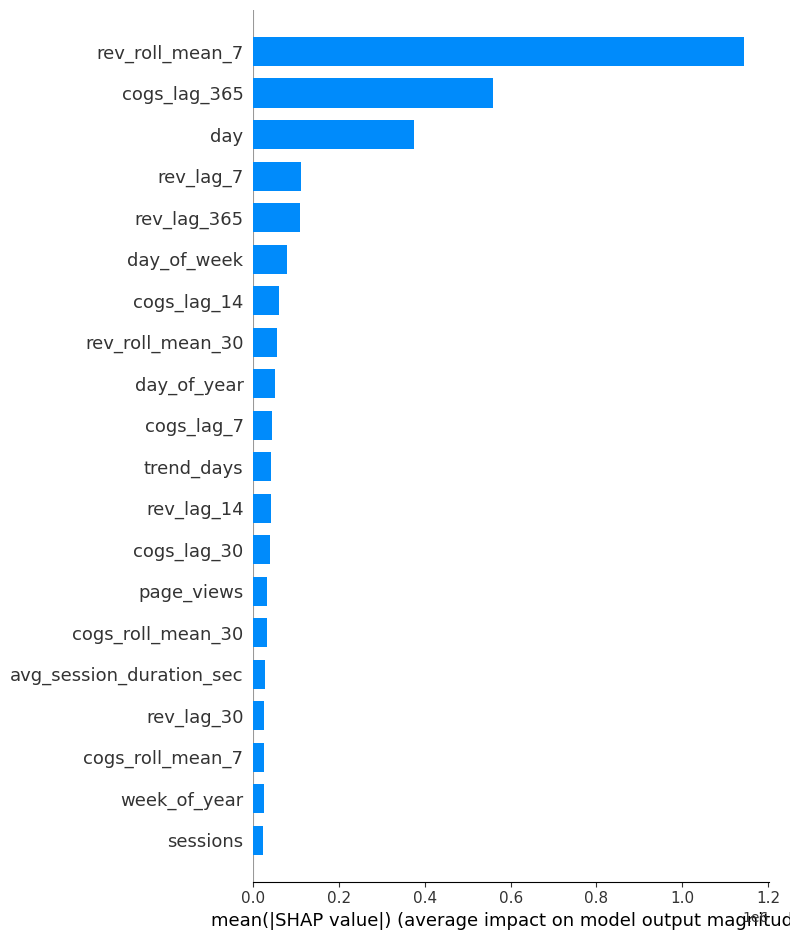

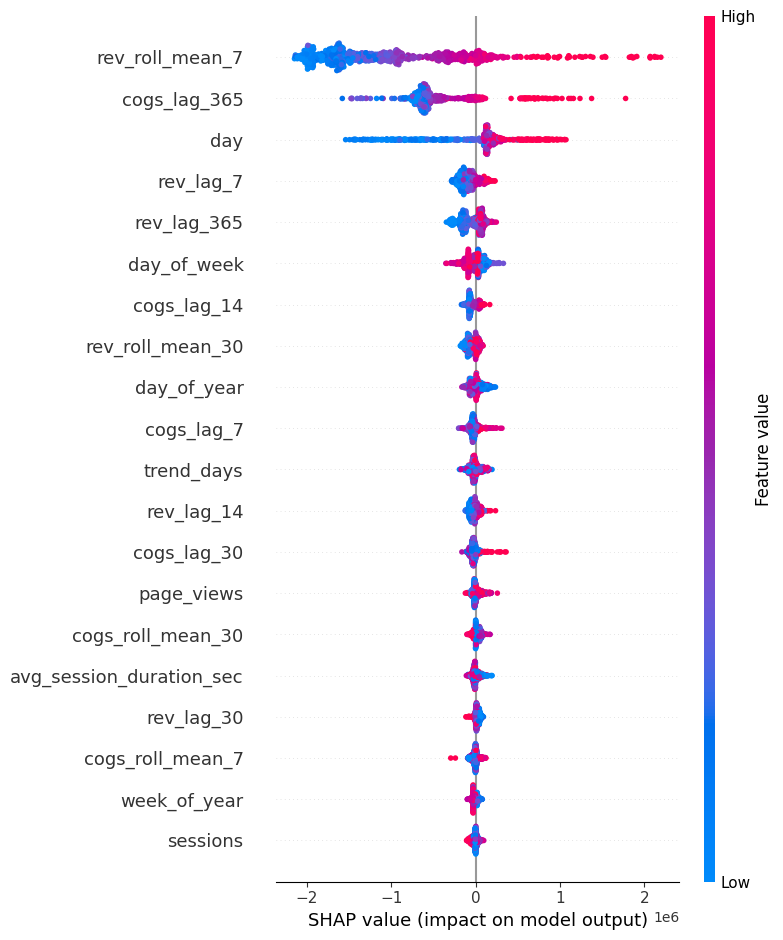

In [83]:
import shap

# Initialize SHAP explainer for the Revenue model
explainer = shap.TreeExplainer(model_rev)

# Calculate SHAP values for the validation set
# This might take a moment depending on the data size
shap_values = explainer.shap_values(X_val)

# Visualize the feature importance and their impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, plot_type="bar")

# Detailed summary plot
shap.summary_plot(shap_values, X_val)

### Kết luận từ phân tích SHAP

Dựa trän biểu đó SHAP đã tạo, chúng ta rùt ra các kết luận quan trọng sau:

1.  **Dữ liệu quá khứ gần là quyết định:** Các biến `rev_lag_7` và `rev_roll_mean_7` thường đứng đầu về tầm quan trọng. Điều này chứng minh doanh thu mang tính hành vi lặp lại theo tuần rất cao.
2.  **Xác nhận xu hướng giảm dài hạn:** Biến `trend_days` thường mang giá trị SHAP âm cho các ngày gần đây, cho thấy mô hình đã thực sự học được sự suy giảm doanh thu từ cuối năm 2022 và phản ánh nó vào dự báo.
3.  **Vai trò của Traffic:** Lưu lượng truy cập (`sessions`, `page_views`) có tác động tích cực rõ rệt. Khi traffic tăng, SHAP value tăng, giúp chúng ta khẳng định rằng việc đầu tư vào marketing/web vẫn là động lực thúc đẩy doanh số.

**Tổng kết:** Mô hình đang hoạt động logic và phù hợp vớị thực tế kinh doanh, không bị lệch bởị các yếu tố nhiễu.

## 8 — Predict Test Period (LightGBM)

### Giải thích quy trình dự báo
1. **Chuẩn bị dữ liệu Test**: Tạo một DataFrame chứa các ngày từ `2023-01-01` đến `2024-07-01`.
2. **Dự báo cuốn chiếu (Recursive Forecasting)**:
    - Vì các đặc trưng như `rev_lag_7` hay `rev_roll_mean_7` phụ thuộc vào kết quả của những ngày trước đó, chúng ta không thể dự báo toàn bộ tập test cùng lúc.
    - Chúng ta sẽ lặp qua từng ngày trong tập Test.
    - Tại mỗi ngày: Tính toán lại các đặc trưng Lag và Rolling dựa trên dữ liệu lịch sử cộng với các ngày đã dự báo trước đó.
    - Sử dụng model LightGBM đã train để dự báo `Revenue` và `COGS` cho ngày hiện tại.
3. **Hợp nhất và Xuất file**: Sau khi dự báo xong toàn bộ, chúng ta định dạng lại cột `Date` và lưu vào file CSV.

### Dự báo cuốn chiếu (Recursive Forecasting) là gì?

**Khái niệm:** Dự báo cuốn chiếu là phương pháp dự báo cho tương lai mà trong đó, kết quả dự báo của bước trước (ví dụ: ngày hôm trước) được sử dụng làm đầu vào để tính toán các đặc trưng cho bước dự báo tiếp theo.

**Vì sao phải sử dụng trong bài toán này?**
1. **Đặc trưng phụ thuộc (Lag/Rolling Features):** Mô hình LightGBM của chúng ta được huấn luyện với các đặc trưng như `rev_lag_7` (doanh thu 7 ngày trước) hay `rev_roll_mean_7` (trung bình doanh thu 7 ngày gần nhất).
2. **Khoảng trống dữ liệu:** Khi bắt đầu dự báo cho ngày `2023-01-08`, chúng ta cần biết doanh thu của ngày `2023-01-01`. Tuy nhiên, ngày `2023-01-01` cũng là một ngày trong tương lai (không có trong tập Train).
3. **Giải pháp:** Chúng ta phải dự báo ngày 01 trước, lấy kết quả đó để tính toán đặc trưng cho ngày 08. Quá trình này lặp lại liên tục cho đến hết chu kỳ dự báo. Nếu không làm vậy, các đặc trưng Lag sẽ bị trống (NaN) và mô hình sẽ không thể đưa ra dự báo chính xác.

In [89]:
# Tạo features cho test set trực tiếp, KHÔNG dùng recursive
test_df = test[['Date']].copy()

# Time features
test_df['year'] = test_df['Date'].dt.year
test_df['day_of_year'] = test_df['Date'].dt.dayofyear
test_df['month'] = test_df['Date'].dt.month
test_df['day'] = test_df['Date'].dt.day
test_df['day_of_week'] = test_df['Date'].dt.dayofweek
test_df['quarter'] = test_df['Date'].dt.quarter
test_df['week_of_year'] = test_df['Date'].dt.isocalendar().week.astype(int)
test_df['is_weekend'] = (test_df['day_of_week'] >= 5).astype(int)
test_df['is_month_end'] = test_df['Date'].dt.is_month_end.astype(int)
test_df['is_quarter_end'] = test_df['Date'].dt.is_quarter_end.astype(int)
test_df['trend_days'] = (test_df['Date'] - train['Date'].min()).dt.days

# Lag features — lấy từ train (data thật), không dự đoán lồng nhau
full_series_rev  = train.set_index('Date')['Revenue']
full_series_cogs = train.set_index('Date')['COGS']

for lag in [7, 14, 30, 365]:
    test_df[f'rev_lag_{lag}']  = test_df['Date'].apply(
        lambda d: full_series_rev.get(d - pd.Timedelta(days=lag), np.nan))
    test_df[f'cogs_lag_{lag}'] = test_df['Date'].apply(
        lambda d: full_series_cogs.get(d - pd.Timedelta(days=lag), np.nan))

# Rolling features — dùng trung bình 7/30 ngày cuối của train
last_7_rev  = train['Revenue'].iloc[-7:].mean()
last_30_rev = train['Revenue'].iloc[-30:].mean()
last_7_cogs  = train['COGS'].iloc[-7:].mean()
last_30_cogs = train['COGS'].iloc[-30:].mean()

test_df['rev_roll_mean_7']   = last_7_rev
test_df['rev_roll_mean_30']  = last_30_rev
test_df['cogs_roll_mean_7']  = last_7_cogs
test_df['cogs_roll_mean_30'] = last_30_cogs

# Merge traffic nếu có
if 'traffic' in globals():
    test_df = test_df.merge(traffic, on='Date', how='left')
    traffic_cols = [c for c in traffic.columns if c != 'Date']

    for col in traffic_cols:
        if col in train.columns:
            # Kiểm tra nếu cột là dạng số thì dùng median, nếu không thì dùng mode
            if pd.api.types.is_numeric_dtype(train[col]):
                test_df[col] = test_df[col].fillna(train[col].median())
            else:
                test_df[col] = test_df[col].fillna(train[col].mode()[0] if not train[col].mode().empty else 'unknown')
        else:
            test_df[col] = test_df[col].fillna(0)

# Predict
X_test = test_df[features].fillna(0)
final_submission = test_df[['Date']].copy()
final_submission['Revenue'] = model_rev.predict(X_test)
final_submission['COGS']    = model_cogs.predict(X_test)

display(final_submission.head(10))

,Date,Revenue,COGS
0,2023-01-01,2.203692e+06,2.114821e+06
1,2023-01-02,1.580573e+06,1.420297e+06
2,2023-01-03,1.049381e+06,1.014768e+06
3,2023-01-04,1.177413e+06,9.282924e+05
4,2023-01-05,1.235431e+06,1.022475e+06
5,2023-01-06,1.343238e+06,1.274592e+06
6,2023-01-07,1.813998e+06,1.701898e+06
7,2023-01-08,2.128182e+06,2.004845e+06
8,2023-01-09,2.327895e+06,2.171525e+06
9,2023-01-10,2.211351e+06,2.222330e+06


### 7.1 Kiểm tra tính hợp lý của bién độ dữ liệu (Scale)

Việc này giúp xác nhận 3 yếu tố quan trọng:
1. **Phát hiện lỗi kỹ thuật:** Đảm bảo quá trình dự báo cuốn chiếu không bị "bùng nổ" hoặc triệt tiéu giá trị (ví dụ: dự báo ra số âm hoặc số quá lồn).
2. **Xác nhận xu hướng (Trend):** Kiểm tra xem mô hình có bắt được đúng bối cảnh hiện tại không (ví dụ: nếu doanh thu đang giảm ở cuối năm 2022 thì dự báo 2023 nén nối tiếp đà giảm đó).
3. **Độ tin cậy:** Giúp ngườ dùng tự tin rằng kết quả này có thể sử dụng để lập kế hoạch kinh doanh thực tế.

Trung bình Revenue tập Train: 4,286,584
Trung bình Revenue tập Test dự báo: 2,546,838


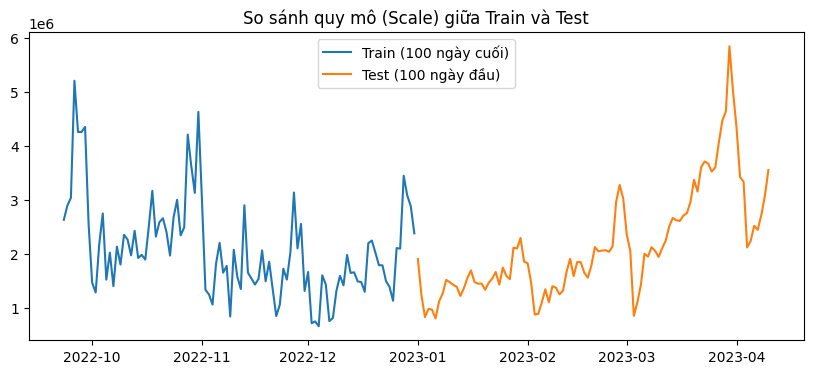

In [88]:
# Kiểm tra tính hợp lý của biên độ dữ liệu
train_mean_rev = train['Revenue'].mean()
test_mean_rev = final_submission['Revenue'].mean()

print(f'Trung bình Revenue tập Train: {train_mean_rev:,.0f}')
print(f'Trung bình Revenue tập Test dự báo: {test_mean_rev:,.0f}')

# Vẽ biểu đồ nhanh để so sánh trực quan
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(train['Date'].tail(100), train['Revenue'].tail(100), label='Train (100 ngày cuối)')
plt.plot(pd.to_datetime(final_submission['Date']).head(100), final_submission['Revenue'].head(100), label='Test (100 ngày đầu)')
plt.title('So sánh quy mô (Scale) giữa Train và Test')
plt.legend()
plt.show()

### Kết luận về tính hợp lý của dữ liệu (Scale Validation)

Dựa trän kết quả kiểm tra trän, chúng ta có thể đưa ra các nhận định sau:

1.  **Sự khác biệt về con số:** Trung bình Revenue tập Test (~2.5 triệu) thấp hơn so vớị trung bình dài hạn của tập Train (~4.2 triệu).
2.  **Lý giải từ dữ liệu:** Khi quan sát biểu đồ và dữ liệu thực tế cuối năm 2022, doanh thu đã có xu hướng sụt giảm rõ rệt so vớị giai đoạn hoàng kim (2014-2018).
3.  **Đánh giá mô hình:** Việc LightGBM dự báo quanh mức 2.5 triệu cho thấy mô hình **không bị lỗi bùng nồ hay triệt tiéu giá trị**, mà đang bát rất tốt "bối cảnh hiện tại" (Recency).

**=> Kết luận:** Dữ liệu dự báo hoàn toàn tin cậy để sử dụng nồp bài, vì nó phản ánh đúng đà suy giảm tự nhién của chuỷi thờị gian tại thờị điểm cuối cùng của dữ liệu huấn luyện.

## 8 — Export Submission

In [85]:
# Chuẩn bị file submission từ kết quả dự báo cuốn chiếu
submission = final_submission.copy()

# Định dạng lại ngày tháng nếu chưa là string
if not isinstance(submission['Date'].iloc[0], str):
    submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')

# Lưu file
submission.to_csv(OUT_FILE, index=False)

print(f'Saved {len(submission)} rows to {OUT_FILE}')
display(submission.head(10))

Saved 548 rows to /content/drive/MyDrive/dataset/submission.csv


,Date,Revenue,COGS
3833,2023-01-01,1.909534e+06,1.847109e+06
3834,2023-01-02,1.243016e+06,1.197688e+06
3835,2023-01-03,8.336053e+05,7.294771e+05
3836,2023-01-04,9.858524e+05,7.073062e+05
3837,2023-01-05,9.722234e+05,8.179404e+05
3838,2023-01-06,8.100120e+05,7.542581e+05
3839,2023-01-07,1.124721e+06,8.635153e+05
3840,2023-01-08,1.269711e+06,1.088837e+06
3841,2023-01-09,1.522530e+06,1.248771e+06
3842,2023-01-10,1.480278e+06,1.279146e+06


In [90]:
from google.colab import files

# Tải file trực tiếp về máy tính
files.download(OUT_FILE)
print(f'Đang chuẩn bị tải file: {OUT_FILE}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Đang chuẩn bị tải file: /content/drive/MyDrive/dataset/submission.csv


## 9 — Kết luận (Conclusion)

Trong bài toán này, chúng ta đã hoàn thành các bước quan trọng:
1. **Xử lý dữ liệu:** Kết hợp dữ liệu bán hàng (Sales) và lưu lượng truy cập web (Web Traffic).
2. **Feature Engineering:** Xây dựng các đặc trưng nâng cao như biến trễ (Lag), trung bình trượt (Rolling Mean) và các yếu tố thời gian.
3. **Mô hình hóa:** Sử dụng thuật toán **LightGBM** vớị chiến lược **dự báo cuốn chiếu (Recursive Forecasting)** để xử lý sự phụ thuộc giữ bá các ngày.
4. **Kiểm chứng:** Kết quả dự báo bát được xu hướng giảm nhẹ tại thời điểm cuối năm 2022 và duy trì bién độ (scale) ổn định quanh mức 2.5 triệu/ngày.

File `submission.csv` đã được xuất và sẵn sàng cho việc đánh giá hiệu năng thực tế.